# Adding exponential mass loss/growth

You can always modify the mass of particles between calls to `sim.integrate`.  However, if you want to apply the mass/loss growth every timestep *within* calls to `sim.integrate`, you should use this.

We begin by setting up a system with 3 planets.

In [82]:
import rebound
import reboundx
import numpy as np
import matplotlib as plt

M0 = 1. # initial mass of star

def makesim():
    sim = rebound.Simulation()
    sim.integrator = "whfast"
    sim.G = 4*np.pi**2 # use units of AU, yrs and solar masses

    sim.add(m=M0)
    # sim.add(a=1.)
    # sim.add(a=2.)
    # sim.add(a=3.)
    sim.move_to_com()
    return sim

In [83]:
%matplotlib inline
sim = makesim()
ps = sim.particles
# op = rebound.OrbitPlot(sim)

We now add mass loss through REBOUNDx:

In [84]:
# rebx = reboundx.Extras(sim)
# modifymass = rebx.load_operator("modify_mass")
# rebx.add_operator(modifymass)

Now we set the e-folding mass loss/growth rate.  

**Positive timescales give growth, negative timescales loss.**

Here we have the star lose mass with an e-folding timescale of $10^4$ yrs.

In [85]:
# ps[0].params["tau_mass"] = (-7.e13)/10.

Now we integrate for one e-folding timescale, and plot the resulting system:

In [86]:
Nout = 400
rate = (-7.e14)
mass = np.zeros(Nout)
times = np.linspace(0., -1.e4, Nout)
Rchive = np.zeros(Nout)

for i, time in enumerate(times):
    sim.integrate(time)
    sim.particles[0].m = M0*np.exp(time / rate)
    R = 0.0025696
    mass[i] = sim.particles[0].m
    Rchive[i] = R

We see that after the mass of the star has decayed by a factor of `e`, the scale of the system has expanded by the corresponding factor, as one would expect.  If we plot the mass of the star vs time, compared to an exponential decay, the two overlap.

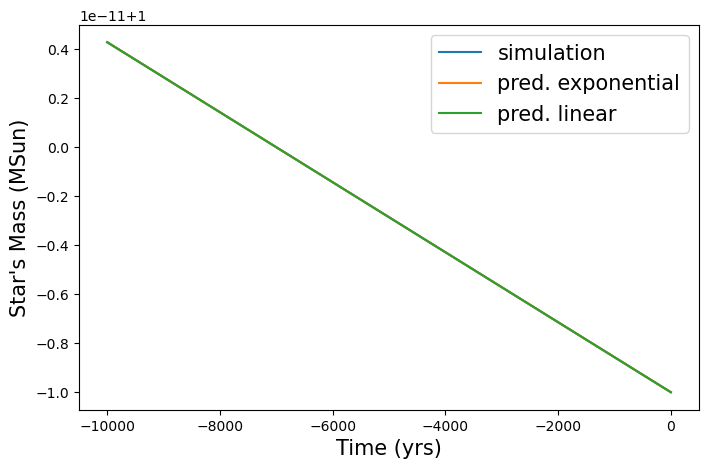

In [87]:
pred2 = M0*(1+(times/rate))
pred = M0*np.exp(times / rate)
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,5))
ax = plt.subplot(111)
ax.plot(times,mass, label='simulation')
ax.plot(times,pred, label='pred. exponential')
ax.plot(times,pred2, label='pred. linear')
ax.set_xlabel("Time (yrs)", fontsize=15)
ax.set_ylabel("Star's Mass (MSun)", fontsize=15)
ax.legend(fontsize=15);

In [88]:
pred[-1]-mass[-1]

0.0

/tmp/ipykernel_327675/2642355363.py:8: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


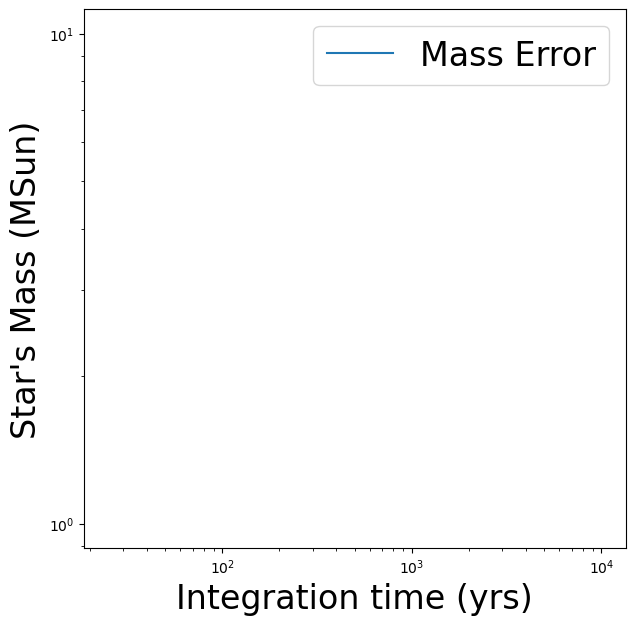

In [89]:
pred2 = M0*(1+(times/rate))
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(111)
ax.plot(abs(times),abs((pred2 - mass)/pred2), label='Mass Error')
# ax.plot(times,abs(pred - mass)/pred, label='diffreal')
# ax.plot(times,pred, label='predicted')
# ax.plot(times,pred2, label='pred approx')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("Integration time (yrs)", fontsize=24)
ax.set_ylabel("Star's Mass (MSun)", fontsize=24)
ax.legend(fontsize=24);

In [145]:
def radii(x):
    y = np.zeros(len(x))
    for i, time in enumerate(x):
        R = 0.0025696
        R_e = (4.2635e-5)
        ratio = R / R_e
        y[i] = ratio-((5.14/ 1.e9)*(abs(time)))
    return y

(-3500000000.0, 0.0)

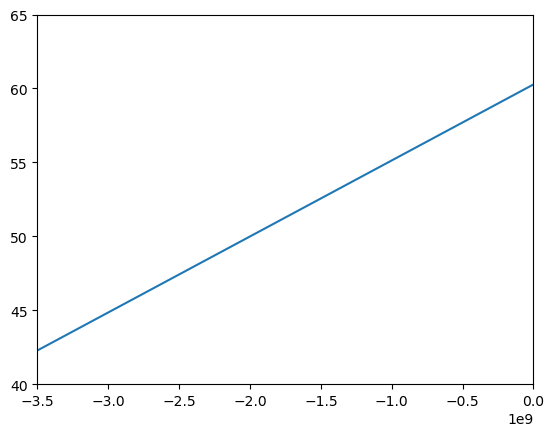

In [146]:
times = np.linspace(0., -3.5*1e9, Nout)

plt.plot(times, radii(times))
plt.ylim(40,65)
plt.xlim(-3.5*1e9,0)